## ML Project (END SEM)

We start by importing all the required libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Reading the dataset

In [2]:
df = pd.read_csv("StudentPerformanceFactors.csv")
df.head()


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


### Basic Analysis of Dataset

In [3]:
# data on all features
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [4]:
# statistics of all features
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


### Checking for null values

In [5]:
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

We can see that Teacher_Quality,Parental_Education_Level,Distance_from_Home columns have null values all are categorical columns so we will replace by mode

In [6]:
for col in df.columns:
    if df[col].dtype in ['int64', 'float64']: 
        mean_value = df[col].mean()
        df[col].fillna(mean_value, inplace=True)
    else: 
        mode_value = df[col].mode()[0]
        df[col].fillna(mode_value, inplace=True)
df.isnull().sum()


Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64

In [7]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


### Checking existence of duplicates:

In [8]:
df = df.drop_duplicates()
df.shape

(6607, 20)

In [9]:
num_cols=[col for col in df.columns if df[col].dtype in ['int64', 'float64']]

### Outlier Detection and Removal

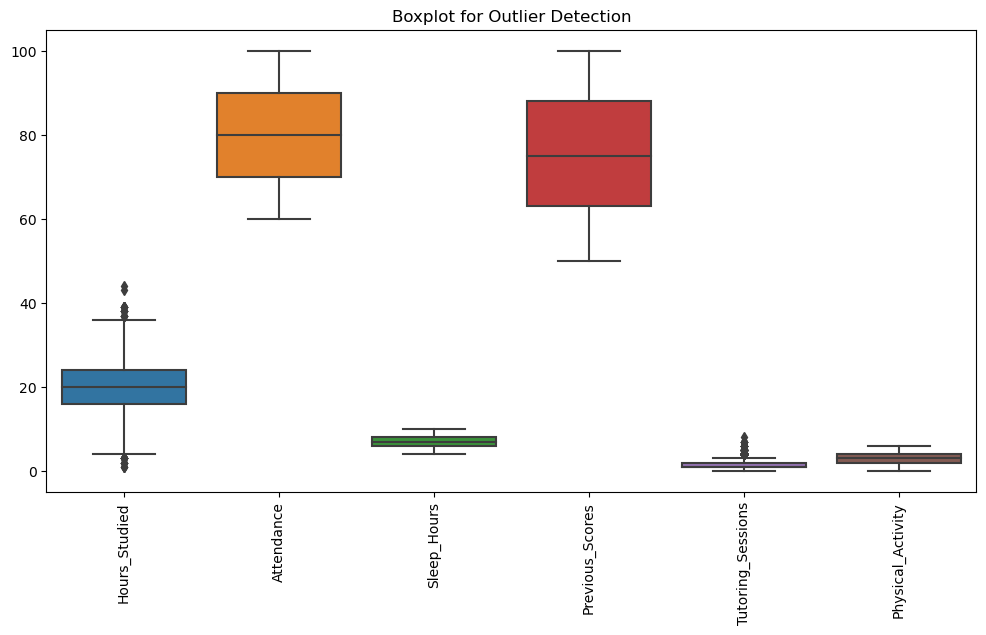

In [10]:
plt.figure(figsize=(12,6))
cols = [col for col in df.columns if df[col].dtype in ['int64', 'float64'] and col != 'Exam_Score']
sns.boxplot(data=df[cols])
plt.xticks(rotation=90)
plt.title("Boxplot for Outlier Detection")
plt.show()

We notice a few outliers in the boxplot. Since the outliers are quite far away from the IQR, they can be removed.

In [11]:
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

ol = ((df[num_cols] < (Q1 - 1.5 * IQR)) | (df[num_cols] > (Q3 + 1.5 * IQR)))
ol_iqr = ol.any(axis=1)
print(f'No. of outliers: {np.sum(ol_iqr)}')
df = df[~ol_iqr]

No. of outliers: 553


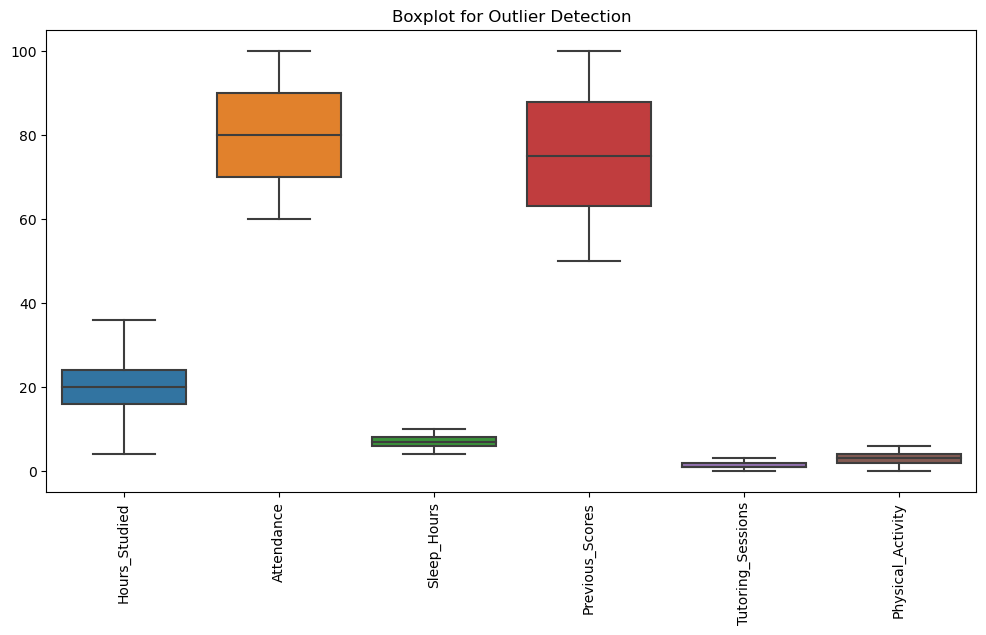

In [12]:
plt.figure(figsize=(12,6))
cols = [col for col in df.columns if df[col].dtype in ['int64', 'float64'] and col != 'Exam_Score']
sns.boxplot(data=df[cols])
plt.xticks(rotation=90)
plt.title("Boxplot for Outlier Detection")
plt.show()

### Exploratory Data Analysis

#### Univariate Analysis

#### Numerical Features

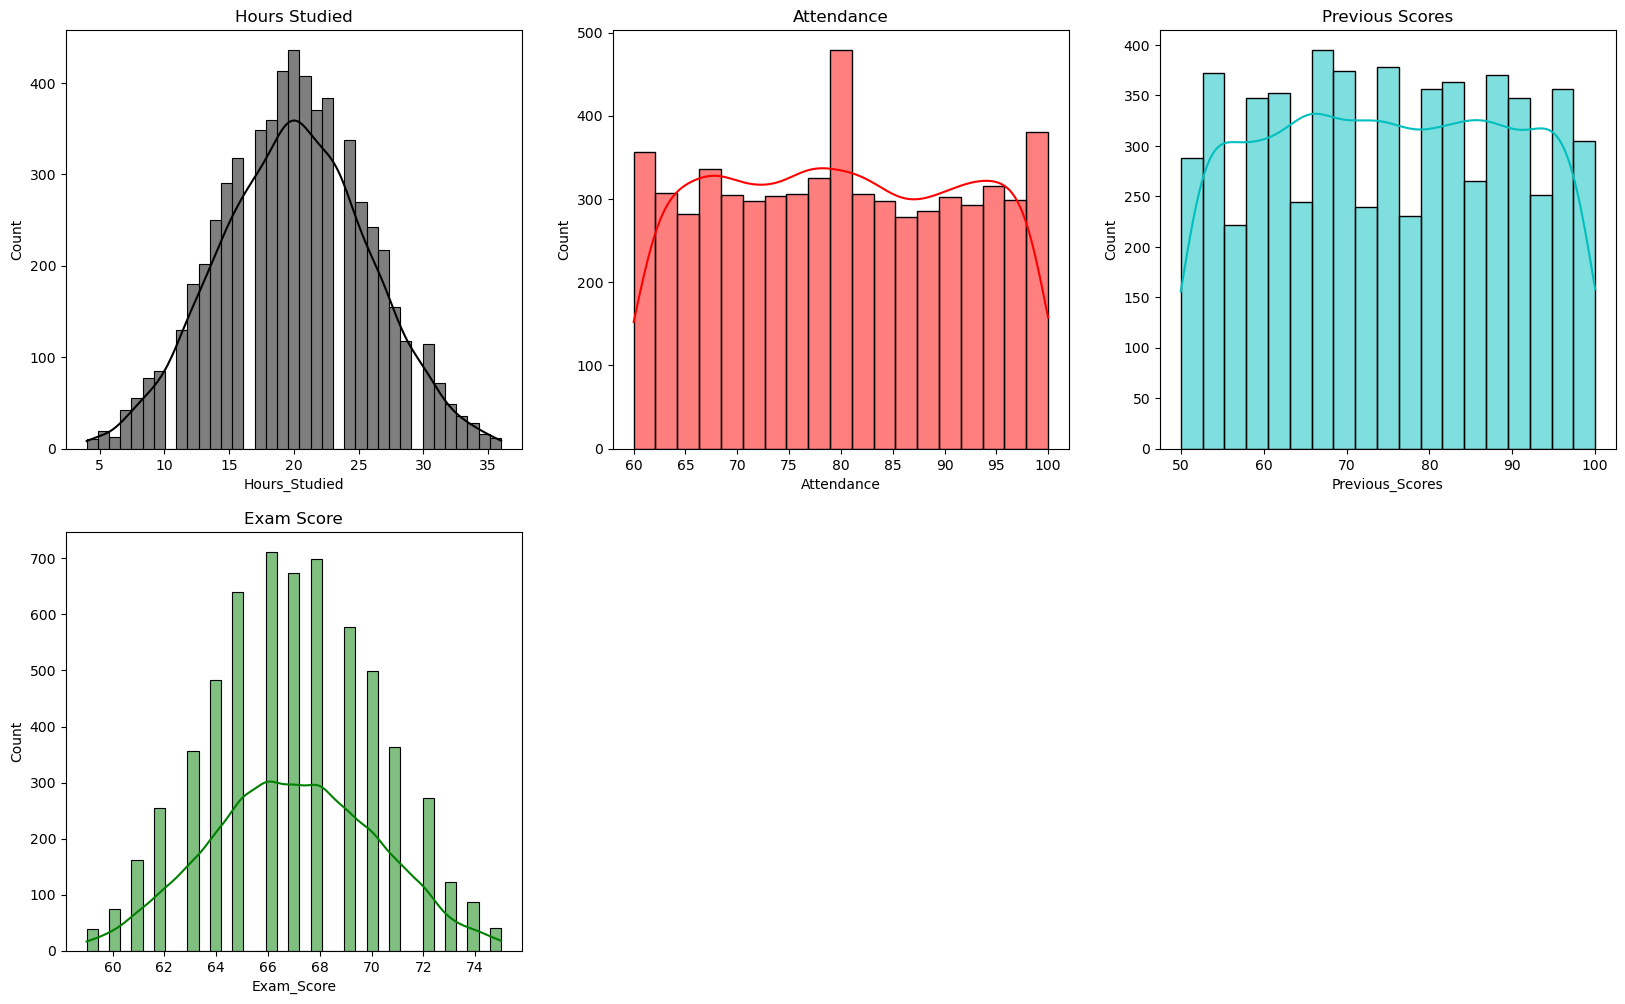

In [13]:
colors = ['k', 'r', 'c', 'g']
num_cols = [col for col in df.columns if df[col].dtype in ['int64', 'float64'] and col not in ['Tutoring_Sessions','Physical_Activity','Sleep_Hours'] ]
plt.figure(figsize=(20, 25))
for i, col in enumerate(num_cols):
    plt.subplot(4, 3, i + 1)
    plt.title(' '.join(col.split('_')).title())
    sns.histplot(df[col], kde=True, color=colors[i % len(colors)])
plt.show()

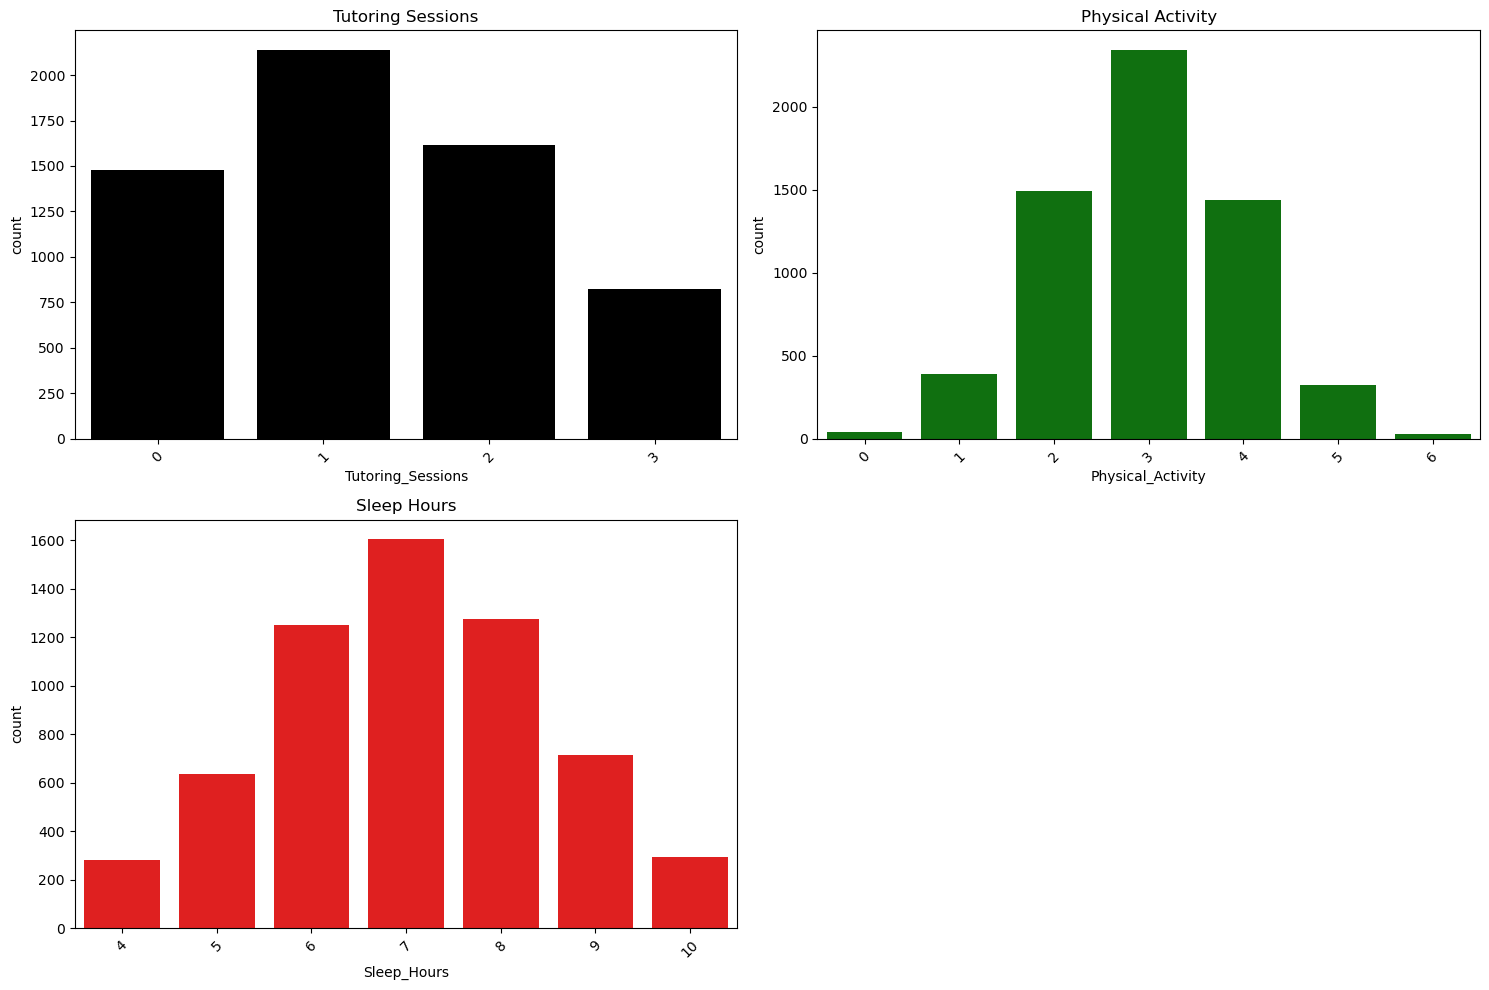

In [14]:
import math

colors = ['k', 'g', 'r', 'c']
cat_cols = ['Tutoring_Sessions','Physical_Activity','Sleep_Hours']
n_cols = 2 
n_rows = math.ceil(len(cat_cols) / n_cols) 

plt.figure(figsize=(15, n_rows * 5)) 

for i, col in enumerate(cat_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    plt.title(' '.join(col.split('_')).title())
    sns.countplot(x=df[col], color=colors[i % len(colors)])
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#### Categorical Features

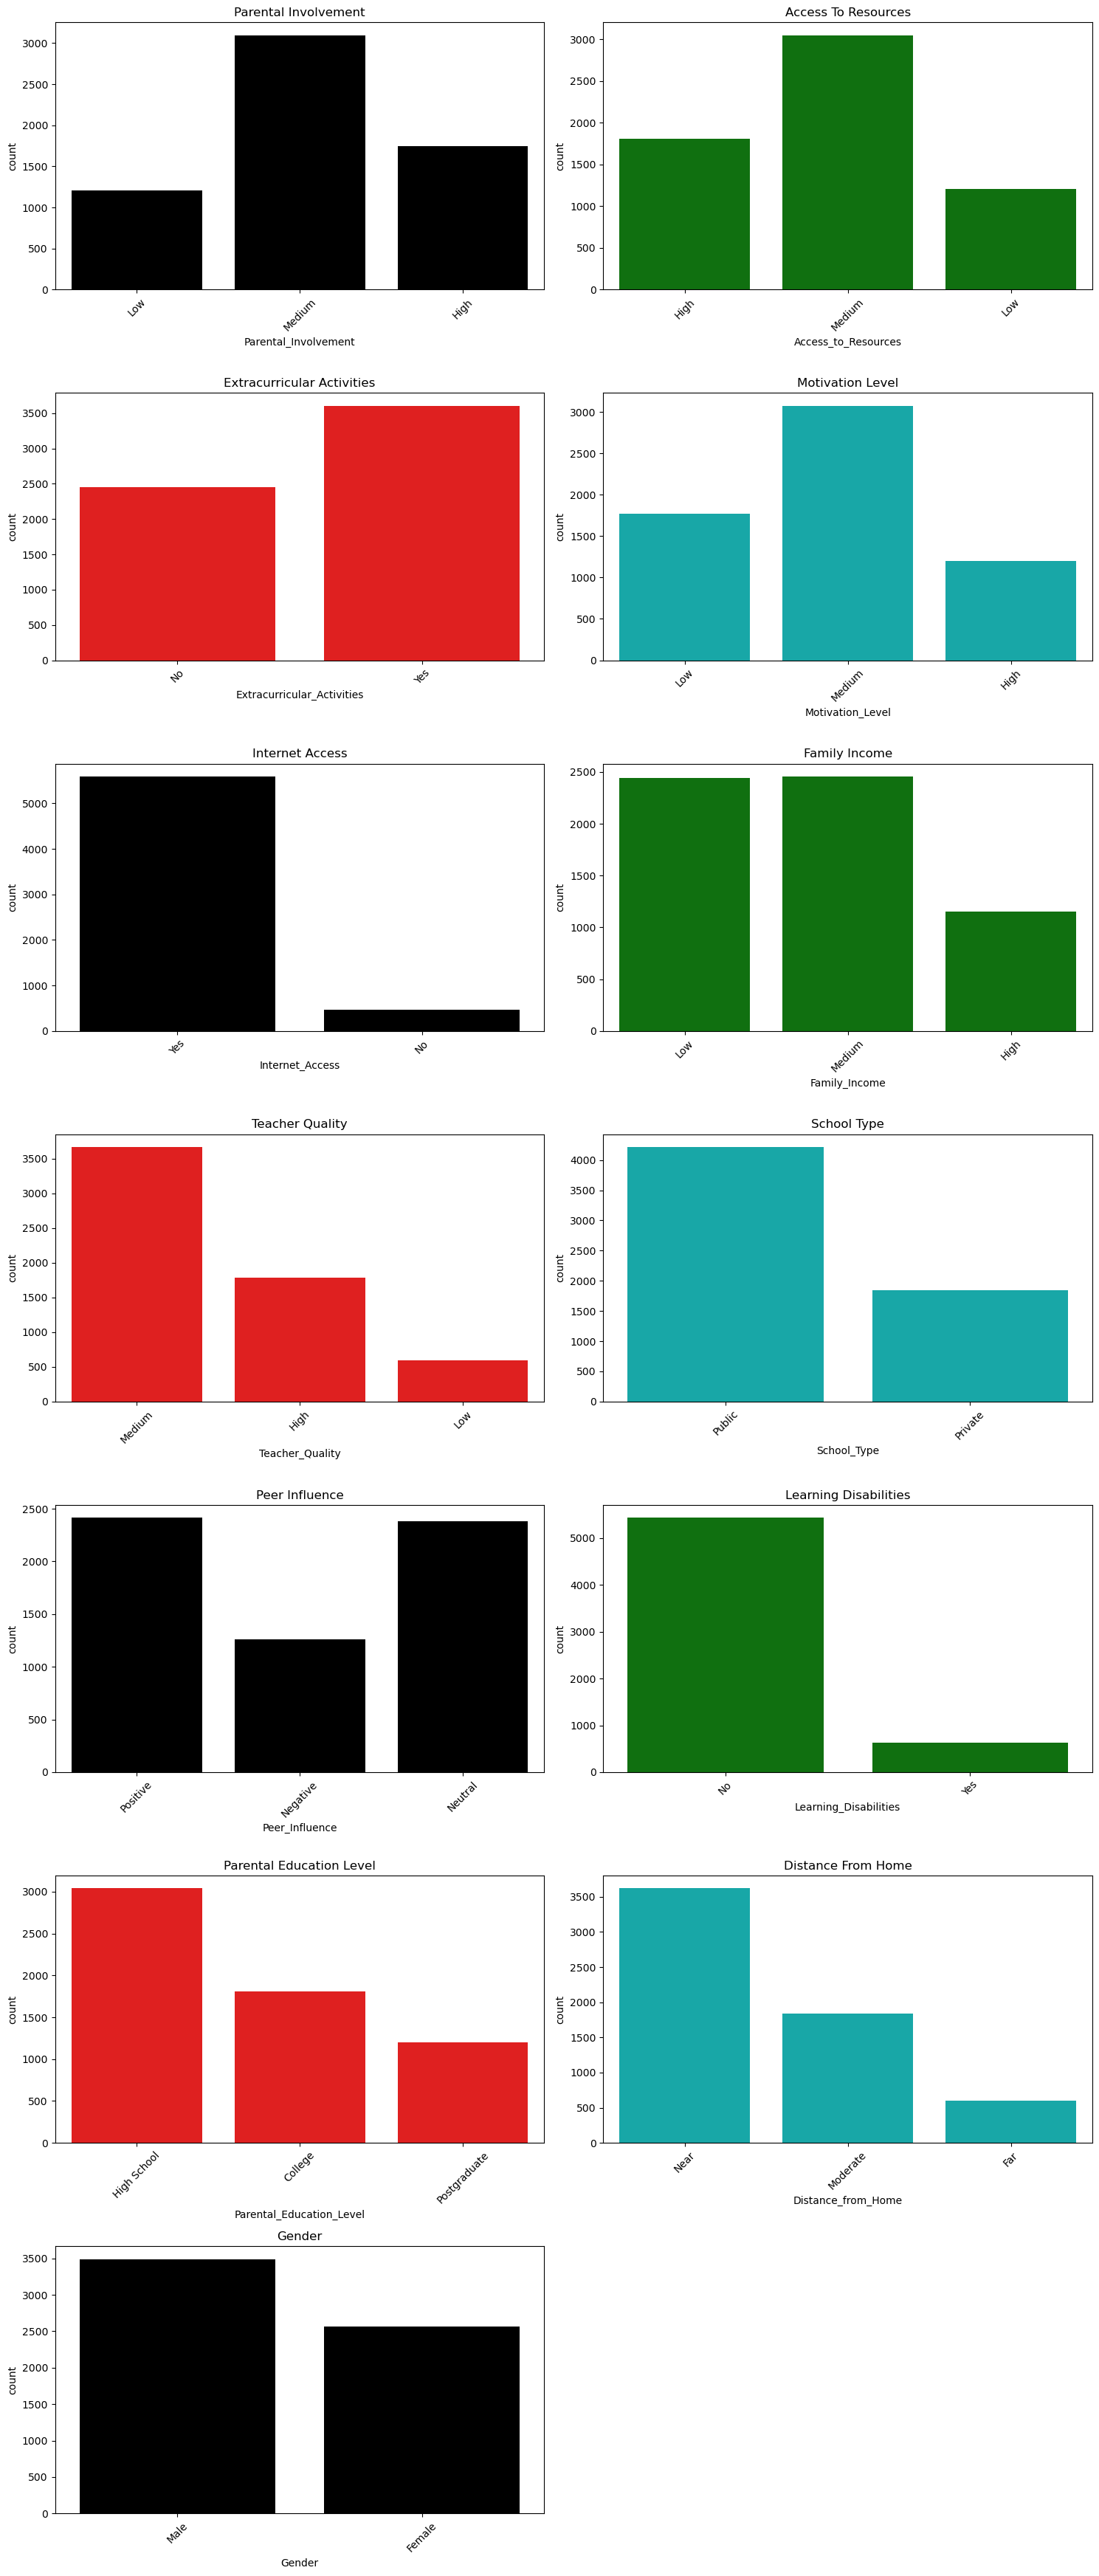

In [15]:
colors = ['k', 'g', 'r', 'c']
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
n_cols = 2 
n_rows = math.ceil(len(cat_cols) / n_cols) 

plt.figure(figsize=(15, n_rows * 5)) 

for i, col in enumerate(cat_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    plt.title(' '.join(col.split('_')).title())
    sns.countplot(x=df[col], color=colors[i % len(colors)])
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

##### Distribution of classes of Target

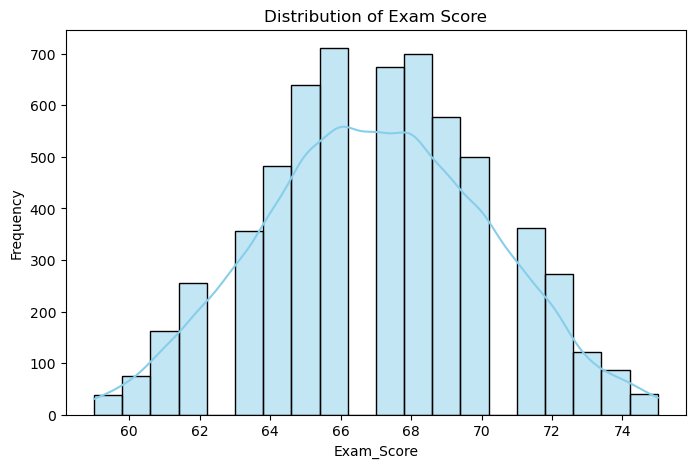

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df['Exam_Score'], kde=True, color='skyblue', bins=20)
plt.title('Distribution of Exam Score')
plt.xlabel('Exam_Score')
plt.ylabel('Frequency')
plt.show()


#### Bivariate Analysis

#### Numerical Features

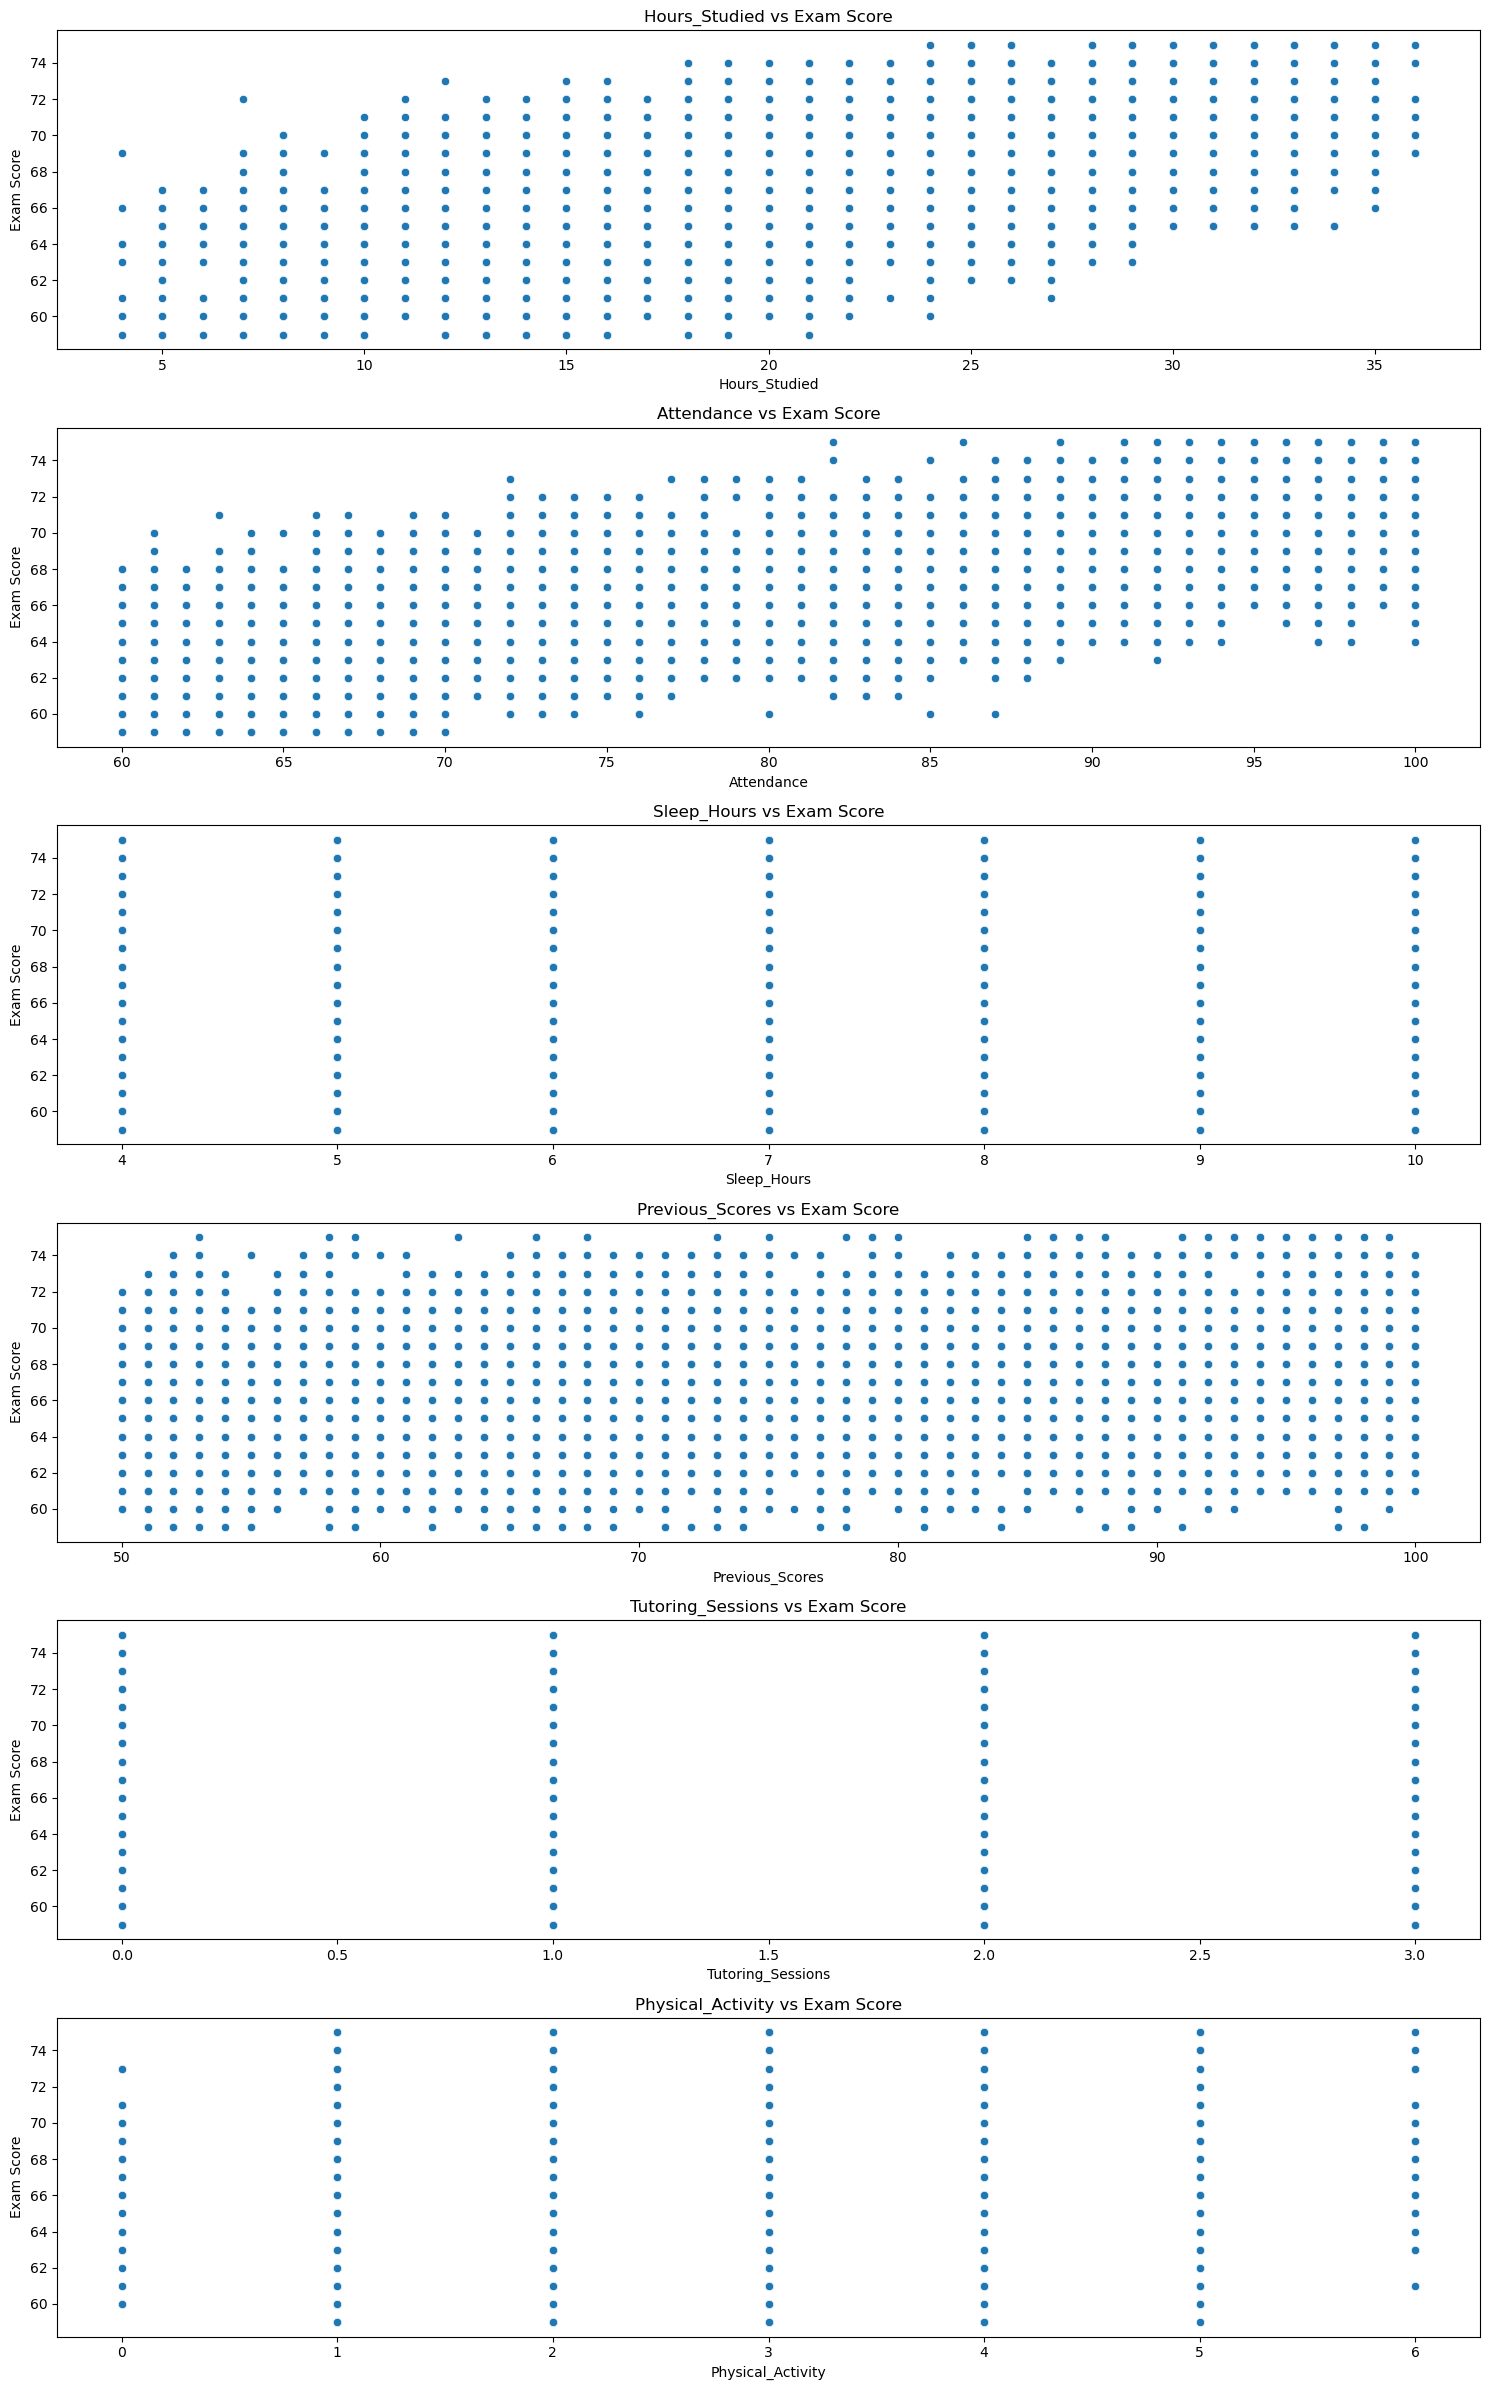

In [17]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols.remove('Exam_Score')  # remove target

plt.figure(figsize=(15, len(num_cols)*4))

for i, col in enumerate(num_cols):
    plt.subplot(len(num_cols), 1, i + 1)
    sns.scatterplot(x=df[col], y=df['Exam_Score'])
    plt.title(f'{col} vs Exam Score')
    plt.xlabel(col)
    plt.ylabel('Exam Score')

plt.tight_layout()
plt.show()


#### Categorical Features

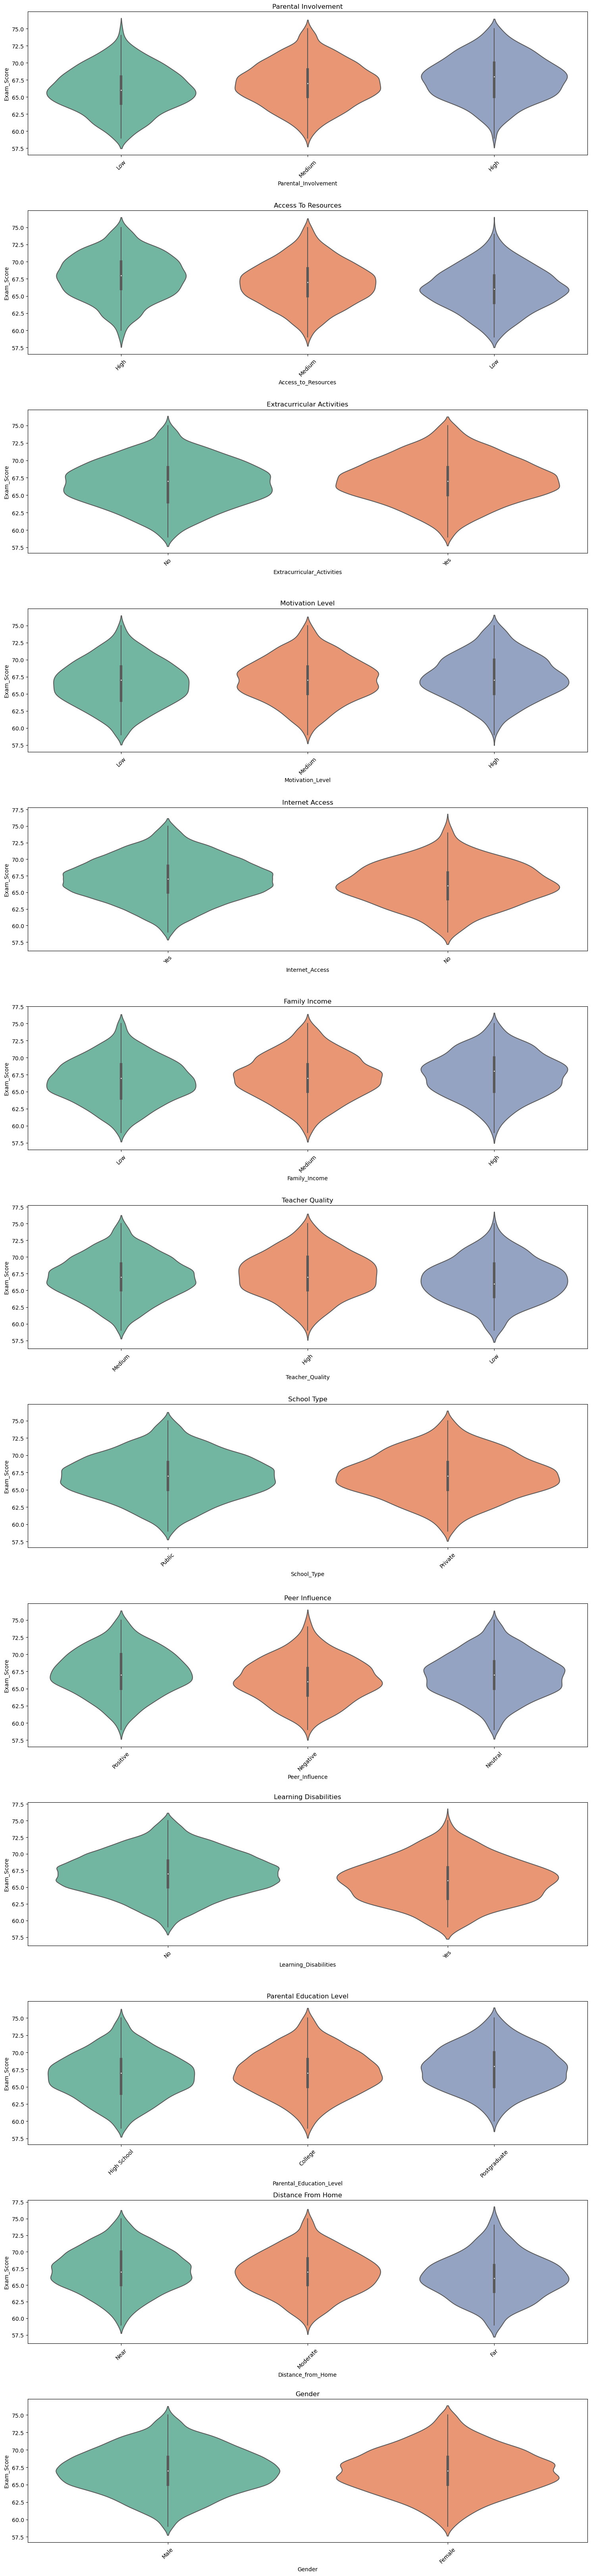

In [18]:
palette = 'Set2'

n_cols = 1
n_rows = math.ceil(len(cat_cols) / n_cols)

plt.figure(figsize=(15, n_rows * 5))

for i, col in enumerate(cat_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.violinplot(x=col, y='Exam_Score', data=df, palette=palette)
    plt.title(" ".join(col.split('_')).title())
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [19]:
from sklearn.preprocessing import LabelEncoder
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical Columns:", len(cat_cols))
num_cols = df.select_dtypes(include=['number']).columns.tolist()
print("Numerical Columns:", len(num_cols))
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

Categorical Columns: 13
Numerical Columns: 7


#### Multivariate Analysis

We plot the heatmap for the dataset to see the correlation between features

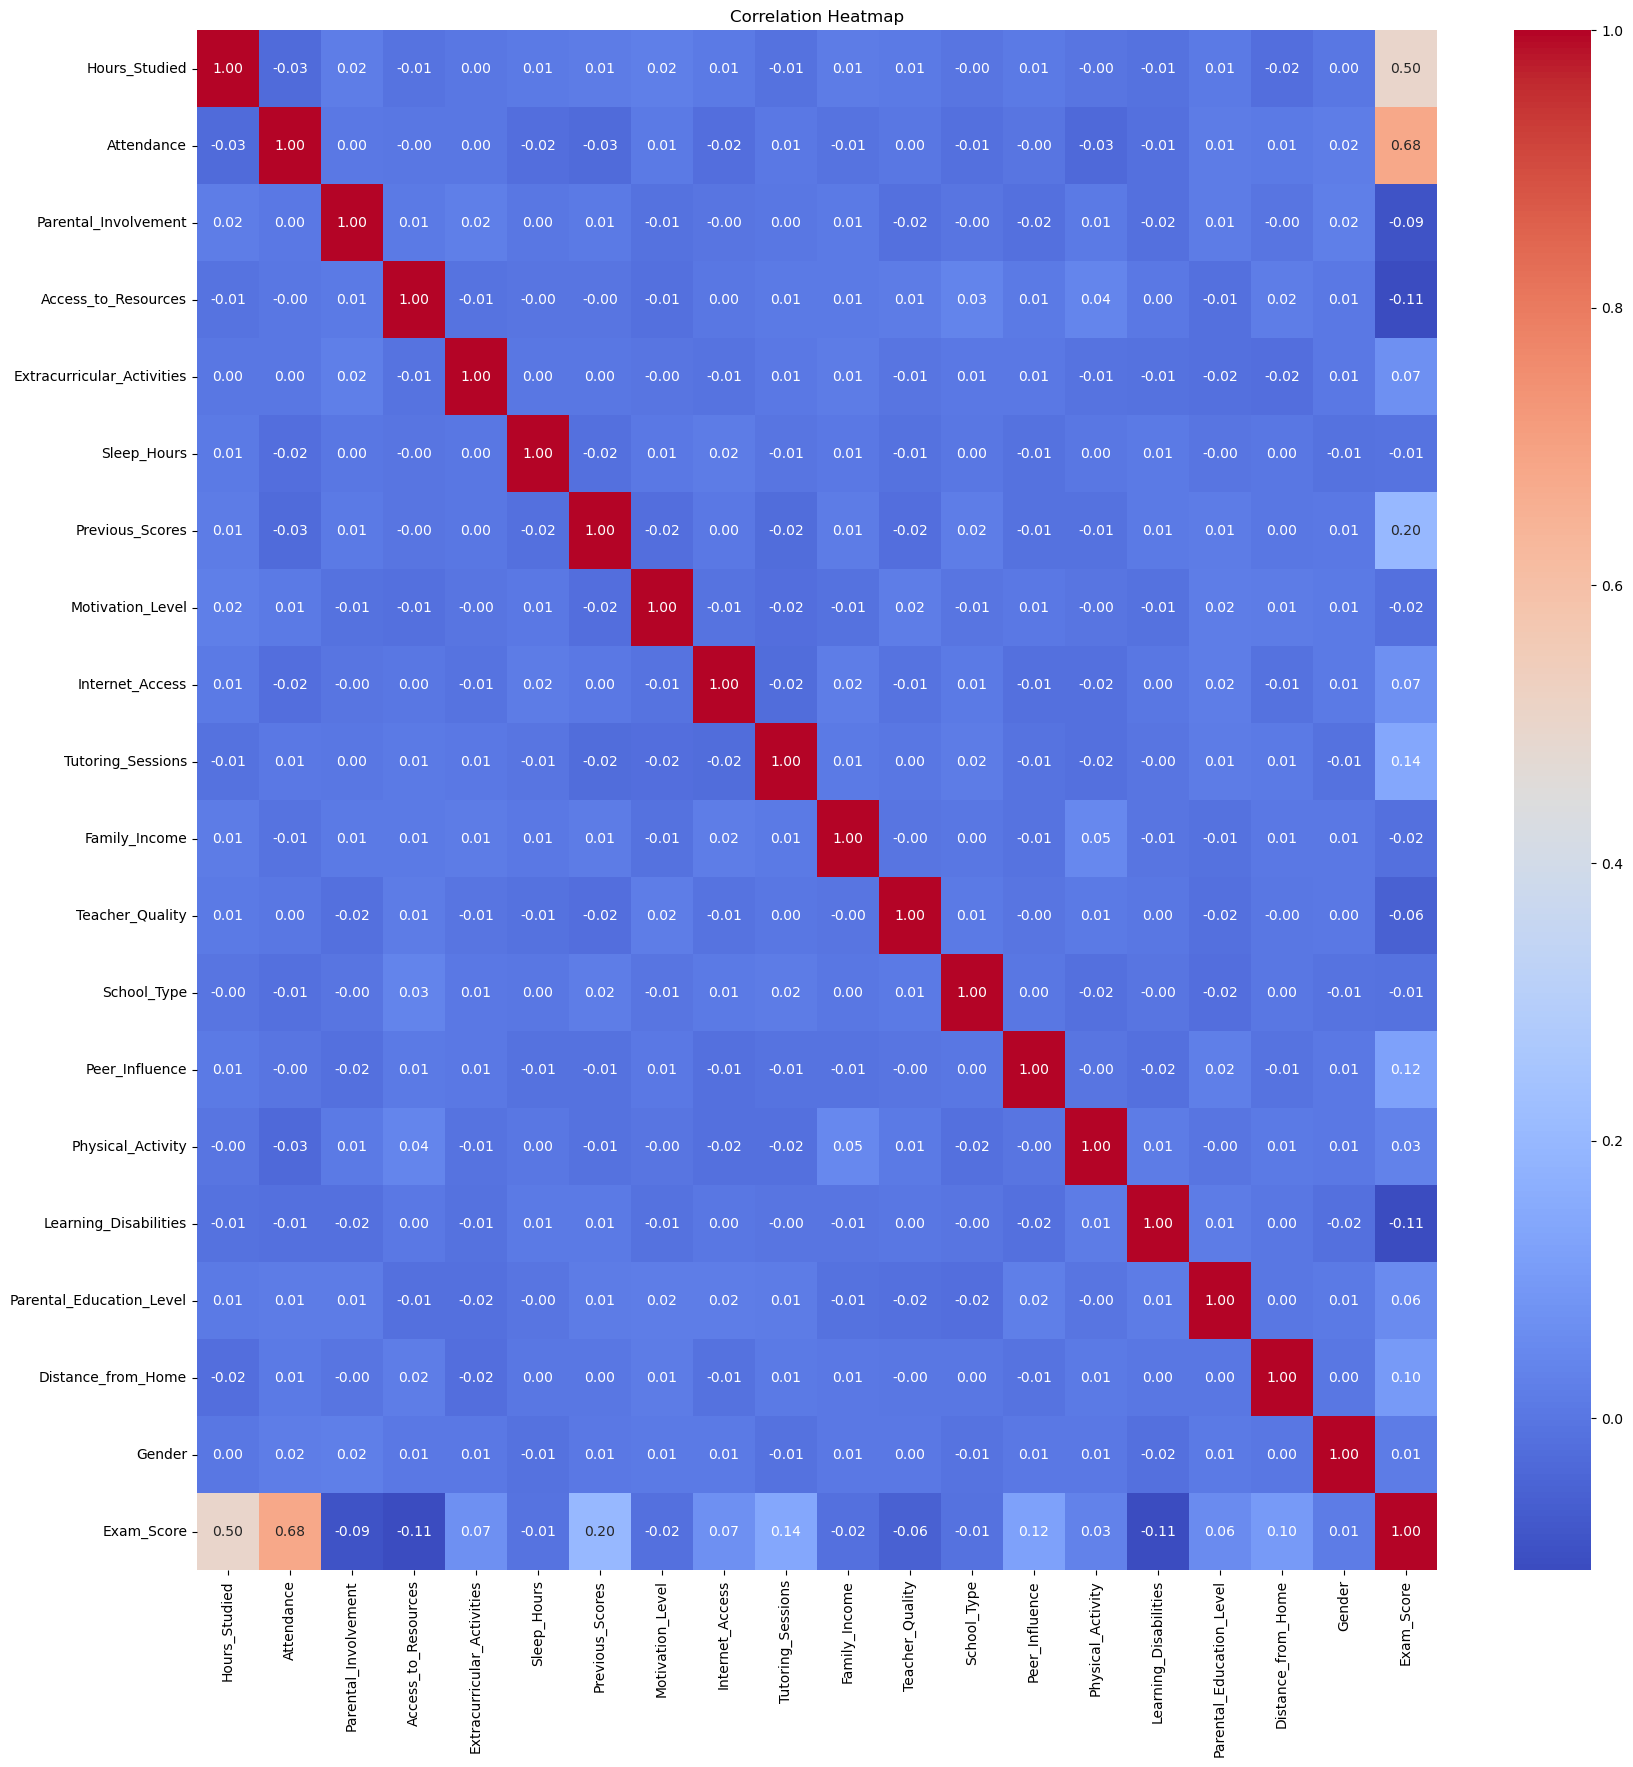

In [20]:
plt.figure(figsize=(20,20))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

we are selecting all the features as maximum correlation is 0.58

In [21]:
# standardization
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
for col in num_cols:
    df[col] = sc.fit_transform(df[col].values.reshape(-1, 1))
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,0.516070,0.350283,1,0,0,-0.023377,-0.147117,1,1,-1.314932,1,2,1,2,0.037064,0,1,2,1,0.005736
1,-0.176485,-1.389206,1,2,0,0.657031,-1.122403,1,1,0.718426,2,2,1,0,1.008430,0,0,1,0,-1.854632
2,0.689209,1.567925,2,2,1,-0.023377,1.106823,2,1,0.718426,2,2,1,1,1.008430,0,2,2,1,2.176166
3,1.554902,0.785155,1,2,1,0.657031,1.594466,2,1,-0.298253,2,2,1,0,1.008430,0,1,1,1,1.245982
4,-0.176485,1.046078,2,2,1,-0.703785,-0.704423,2,1,1.735105,2,0,1,1,1.008430,0,0,2,0,0.935920


## MODEL TRAINING

In [22]:
X = df.drop('Exam_Score',axis=1)
y = df['Exam_Score']

In [23]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2,random_state=42)

### Linear Regression

In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection  import cross_val_score

lr = LinearRegression()
lr.fit(X_train, y_train)

y_train_pred_linear = lr.predict(X_train)
y_test_pred_linear = lr.predict(X_test)

train_acc = r2_score(y_train, y_train_pred_linear)
test_acc = r2_score(y_test, y_test_pred_linear)

print(f"r2 score for train: {train_acc}")
print(f"r2 score for test: {test_acc}")
print(f"mse for train: {mean_squared_error(y_train, y_train_pred_linear)}")
print(f"mse for test: {mean_squared_error(y_test, y_test_pred_linear)}")
cv_scores = cross_val_score(lr, X_train, y_train, cv=5, scoring='r2')
print(f"CV scores:{cv_scores}")
print(f"Average CV score:{cv_scores.mean()}")

r2 score for train: 0.8858488292774884
r2 score for test: 0.8730437143504761
mse for train: 0.11516424837364976
mse for test: 0.1224160479175648
CV scores:[0.87763907 0.88785704 0.88157885 0.8833442  0.89381841]
Average CV score:0.8848475149614987


#### Actual v/s Predicted

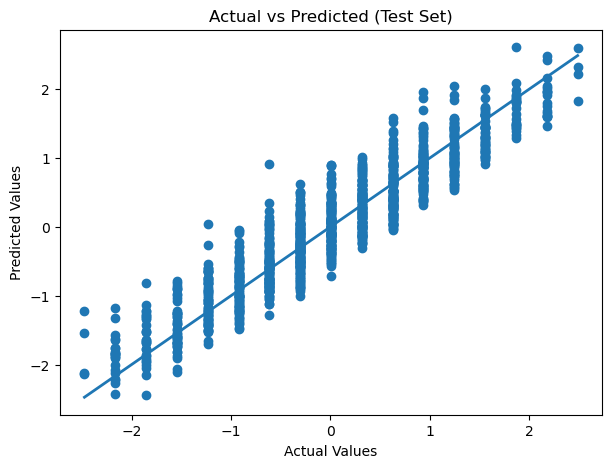

In [25]:
plt.figure(figsize=(7,5))

plt.scatter(y_test, y_test_pred_linear)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linewidth=2)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (Test Set)")
plt.show()

The points do not lie exactly on the diagonal line. We can see that there is vertical spread across the diagonal line, the error is also consistent with the trend and spread is higher for larger values, but we can say that this model fits the data reasonably well the model. It is not perfect but it is an acceptable model.

### Polynomial Regression

In [26]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(5)
X_train_poly=poly.fit_transform(X_train)
X_test_poly=poly.transform(X_test)

In [27]:
plr = LinearRegression()
plr.fit(X_train_poly, y_train)

y_train_pred_poly = plr.predict(X_train_poly)
y_test_pred_poly = plr.predict(X_test_poly)

train_acc = r2_score(y_train, y_train_pred_poly)
test_acc = r2_score(y_test, y_test_pred_poly)

print(f"r2 score for train: {train_acc}")
print(f"r2 score for test: {test_acc}")
print(f"mse for train: {mean_squared_error(y_train, y_train_pred_poly)}")
print(f"mse for test: {mean_squared_error(y_test, y_test_pred_poly)}")
cv_scores = cross_val_score(plr, X_train, y_train, cv=5, scoring='r2')
print(f"CV scores:{cv_scores}")
print(f"Average CV score:{cv_scores.mean()}")

r2 score for train: 1.0
r2 score for test: 0.9061645740488707
mse for train: 3.4981044913857634e-28
mse for test: 0.09047966345919659
CV scores:[0.87763907 0.88785704 0.88157885 0.8833442  0.89381841]
Average CV score:0.8848475149614987


#### Hyperparameter Tuning

In [28]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

pipeline = Pipeline([
    ('poly', PolynomialFeatures()), 
    ('linear', LinearRegression()) 
])

param_grid = {
    'poly__degree': np.arange(1, 6),
}

gscv = GridSearchCV(estimator=pipeline, param_grid=param_grid, scoring='r2', cv=5, verbose=1, n_jobs=-1)
gscv.fit(X_train, y_train)

print(f"Best parameters found: {gscv.best_params_}")
print(f"Best score: {gscv.best_score_}")
best_poly_model = gscv.best_estimator_

test_r2 = best_poly_model.score(X_test, y_test)
y_test_pred_poly = best_poly_model.predict(X_test)
y_train_pred_poly = best_poly_model.predict(X_train)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_poly))

print(f"Test R2: {test_r2}")
print(f"Test RMSE: {test_rmse}")

Fitting 5 folds for each of 5 candidates, totalling 25 fits


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:425: FitFailedWarning: 
3 fits failed out of a total of 25.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
2 fits failed with the following error:
Traceback (most recent call last):
  File "C:\ProgramData\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 732, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py", line 1151, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\site-packages\sklearn\pipeline.py", line 416, in fit
    Xt = self._fit(X, y, **fit_

Best parameters found: {'poly__degree': 2}
Best score: 0.989145437723951
Test R2: 0.9887451775535315
Test RMSE: 0.10417449346460066


#### Learning Curve

[learning_curve] Training set sizes: [ 387  774 1162 1549 1937 2324 2711 3099 3486 3874]


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:    1.0s finished


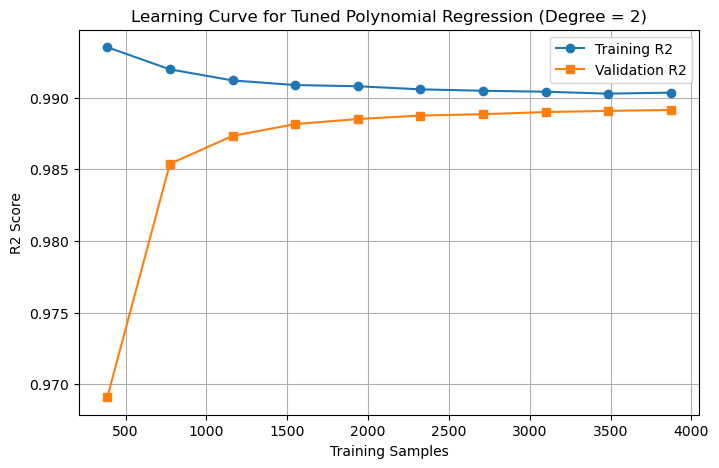

In [29]:
from sklearn.model_selection import learning_curve

best_params = best_poly_model.get_params()
best_degree = best_params['poly__degree']   

poly_final = Pipeline([
    ('poly', PolynomialFeatures(degree=best_degree, include_bias=False)),
    ('linear', LinearRegression())
])

train_sizes, train_scores, test_scores = learning_curve(estimator=poly_final, X=X_train, y=y_train, cv=5, scoring='r2', train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1, verbose=1)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, marker='o', label='Training R2')
plt.plot(train_sizes, test_mean, marker='s', label='Validation R2')

plt.title(f"Learning Curve for Tuned Polynomial Regression (Degree = {best_degree})")
plt.xlabel("Training Samples")
plt.ylabel("R2 Score")
plt.grid(True)
plt.legend()
plt.show()

#### Actual v/s Predicted

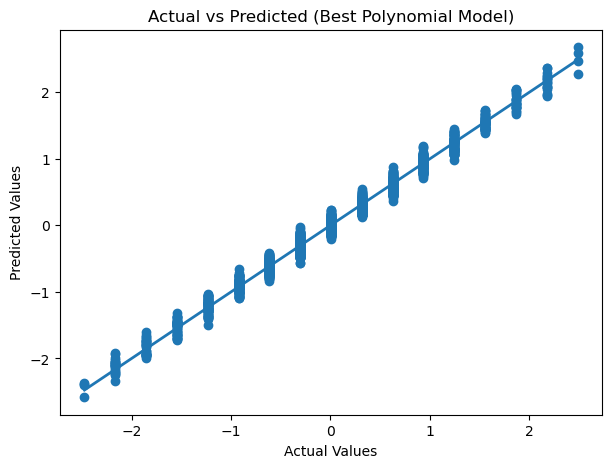

In [30]:
plt.figure(figsize=(7,5))
plt.scatter(y_test,y_test_pred_poly)
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()],
         linewidth=2)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (Best Polynomial Model)")
plt.show()

Polynomial Regression is fitting the pattern better than linear Regression as we can see that the predictions are more accurate than before. But it is slightly overfitting. However, the overall performance is good. The hyperparameter tuning has improved the model very significantly, the new model is extremely accurate.

### LASSO

In [31]:
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import cross_val_score

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

y_train_pred_lasso = lasso.predict(X_train)
y_test_pred_lasso = lasso.predict(X_test)

train_acc = r2_score(y_train, y_train_pred_lasso)
test_acc = r2_score(y_test, y_test_pred_lasso)

print(f"r2 score for train: {train_acc}")
print(f"r2 score for test: {test_acc}")
print(f"mse for train: {mean_squared_error(y_train, y_train_pred_lasso)}")
print(f"mse for test: {mean_squared_error(y_test, y_test_pred_lasso)}")
cv_scores = cross_val_score(lasso, X_train, y_train, cv=5, scoring='r2')
print(f"CV scores:{cv_scores}")
print(f"Average CV score:{cv_scores.mean()}")

r2 score for train: 0.7668924132522732
r2 score for test: 0.751532872690563
mse for train: 0.23517638801319043
mse for test: 0.23958139297347802
CV scores:[0.76876546 0.76276078 0.74618057 0.7791587  0.77206898]
Average CV score:0.7657868973623287


#### Hyperparameter Tuning

In [32]:
# Hyperparameter grid
param_grid = {
    'alpha': np.logspace(-4, 2, 20)   # 0.0001 → 100
}

# GridSearchCV
grid = GridSearchCV(
    estimator=Lasso(max_iter=5000),
    param_grid=param_grid,
    scoring='r2',
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV R2 score:", grid.best_score_)

# Best model
best_lasso = grid.best_estimator_

# Predictions
y_train_pred_lasso = best_lasso.predict(X_train)
y_test_pred_lasso = best_lasso.predict(X_test)

print("Train R2:", r2_score(y_train, y_train_pred_lasso))
print("Test R2:", r2_score(y_test, y_test_pred_lasso))
print("Train MSE:", mean_squared_error(y_train, y_train_pred_lasso))
print("Test MSE:", mean_squared_error(y_test, y_test_pred_lasso))

Best parameters: {'alpha': 0.0001}
Best CV R2 score: 0.8848458229714794
Train R2: 0.8858482407822087
Test R2: 0.8730284308797396
Train MSE: 0.11516484209175301
Test MSE: 0.12243078481756511


#### Actual v/s Predicted

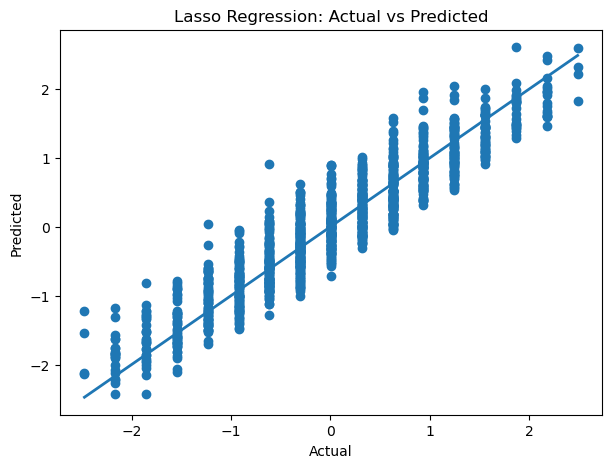

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.scatter(y_test, y_test_pred_lasso)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linewidth=2)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Lasso Regression: Actual vs Predicted")
plt.show()

We can say that the LASSO model has improved after tuning but still it is not perfect.

### Ridge

In [34]:
from sklearn.linear_model import Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

y_train_pred_ridge = ridge.predict(X_train)
y_test_pred_ridge = ridge.predict(X_test)

mse = mean_squared_error(y_test, y_test_pred_ridge)
r2 = r2_score(y_test, y_test_pred_ridge)

print("Mean Squared Error for test:", mse)
print("R2 Score for test:", r2)
cv_scores = cross_val_score(ridge, X_train, y_train, cv=5, scoring='r2')
print(f"CV scores:{cv_scores}")
print(f"Average CV score:{cv_scores.mean()}")

Mean Squared Error for test: 0.12241752832017928
R2 Score for test: 0.8730421790418267
CV scores:[0.87763935 0.88786201 0.88156057 0.88336207 0.89381191]
Average CV score:0.884847183844012


#### Hyperparameter Tuning

In [35]:
param_grid = {
    'alpha': np.logspace(-4, 3, 50)   # 0.0001 to 1000
}

grid = GridSearchCV(estimator=Ridge(), param_grid=param_grid, scoring='r2', cv=5, n_jobs=-1, verbose=1)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV R2 score:", grid.best_score_)

best_ridge = grid.best_estimator_

y_train_pred_ridge = best_ridge.predict(X_train)
y_test_pred_ridge = best_ridge.predict(X_test)

print("Train R2:", r2_score(y_train, y_train_pred_ridge))
print("Test R2:", r2_score(y_test, y_test_pred_ridge))
print("Train MSE:", mean_squared_error(y_train, y_train_pred_ridge))
print("Test MSE:", mean_squared_error(y_test, y_test_pred_ridge))

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameters: {'alpha': 0.0001}
Best CV R2 score: 0.8848475149522222
Train R2: 0.885848829277487
Test R2: 0.8730437142102201
Train MSE: 0.11516424837365126
Test MSE: 0.12241604805280501


#### Actual v/s Predicted

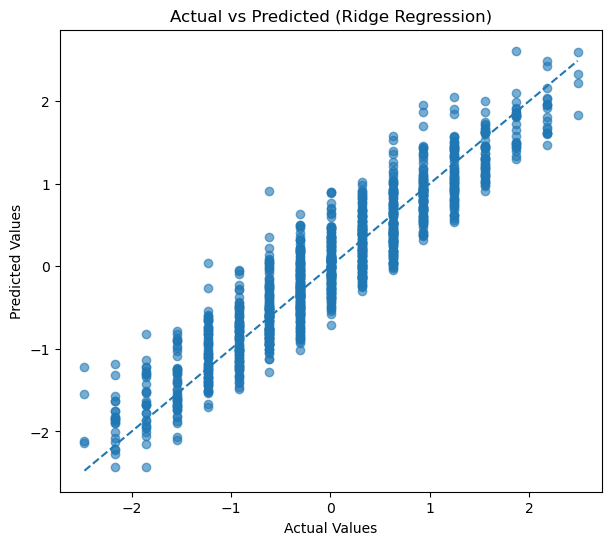

In [36]:
plt.figure(figsize=(7, 6))

plt.scatter(y_test, y_test_pred_ridge, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         linestyle='--')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (Ridge Regression)")
plt.show()

This model is a good model, it captures the trend well but withsome moderate errors.

### Decision Tree

In [37]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)

y_train_pred_dt = dt.predict(X_train)
y_test_pred_dt = dt.predict(X_test)

train_acc = r2_score(y_train, y_train_pred_dt)
test_acc = r2_score(y_test, y_test_pred_dt)

print(f"r2 score for train: {train_acc}")
print(f"r2 score for test: {test_acc}")
print(f"mse for train: {mean_squared_error(y_train, y_train_pred_dt)}")
print(f"mse for test: {mean_squared_error(y_test, y_test_pred_dt)}")
cv_scores = cross_val_score(dt, X_train, y_train, cv=5, scoring='r2')
print(f"CV scores:{cv_scores}")
print(f"Average CV score:{cv_scores.mean()}")

r2 score for train: 1.0
r2 score for test: 0.6668035689130691
mse for train: 6.439119896658708e-34
mse for test: 0.3212805893400228
CV scores:[0.68035798 0.68005411 0.64896172 0.6784326  0.67040287]
Average CV score:0.6716418556557946


#### Hyperparameter Tuning

In [38]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'max_depth': [None] + list(np.arange(1, 20)), 
    'min_samples_split': np.arange(2, 50),       
    'min_samples_leaf': np.arange(1, 25),        
    'max_features': ['auto', 'sqrt', 'log2', None] 
}

dt = DecisionTreeRegressor(random_state=42)

rscv = RandomizedSearchCV(estimator=dt, param_distributions=param_dist, n_iter=50,  cv=5, scoring='r2')

rscv.fit(X_train, y_train)

print(f"Best parameters: {rscv.best_params_}")
print(f"Best cross-validation R2 score: {rscv.best_score_}")
best_dt_model = rscv.best_estimator_
y_train_pred_dt = best_dt_model.predict(X_train)
y_test_pred_dt = best_dt_model.predict(X_test)
train_r2 = best_dt_model.score(X_train, y_train)
test_r2 = best_dt_model.score(X_test, y_test)

print(f"Train R2: {train_r2}")
print(f"Test R2: {test_r2}")

Best parameters: {'min_samples_split': 27, 'min_samples_leaf': 13, 'max_features': None, 'max_depth': 16}
Best cross-validation R2 score: 0.7581077637758696
Train R2: 0.8557747725859031
Test R2: 0.747591294624788


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:425: FitFailedWarning: 
65 fits failed out of a total of 250.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
65 fits failed with the following error:
Traceback (most recent call last):
  File "C:\ProgramData\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 732, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py", line 1144, in wrapper
    estimator._validate_params()
  File "C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py", line 637, in _validate_params
    validate_parameter_constraints(
  File "C:\ProgramData\anaconda3\Lib\site-packages

#### Hyperparameter Tuning

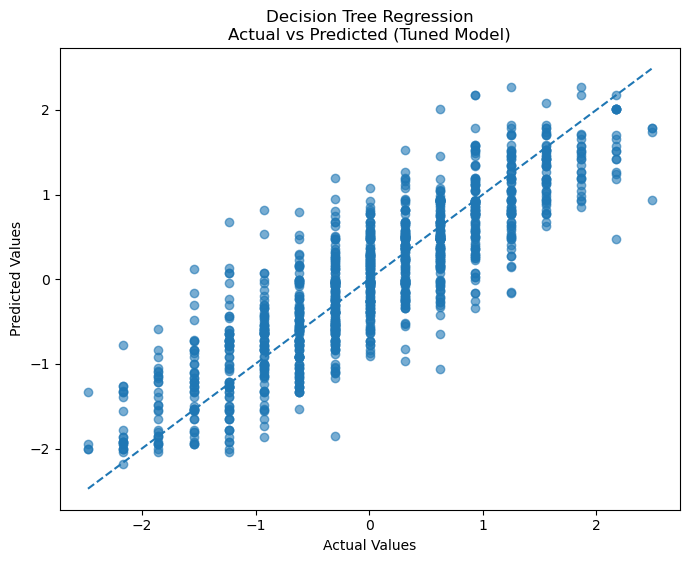

In [39]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_test_pred_dt, alpha=0.6)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)],
         linestyle='--')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Decision Tree Regression\nActual vs Predicted (Tuned Model)")
plt.show()

It performs reasonably well but not it is the best model for this dataset.

### Random Forest

In [41]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

y_train_pred_rf = rf.predict(X_train)
y_test_pred_rf = rf.predict(X_test)

train_acc = r2_score(y_train, y_train_pred_rf)
test_acc = r2_score(y_test, y_test_pred_rf)

print(f"r2 score for train: {train_acc}")
print(f"r2 score for test: {test_acc}")
print(f"mse for train: {mean_squared_error(y_train, y_train_pred_rf)}")
print(f"mse for test: {mean_squared_error(y_test, y_test_pred_rf)}")
cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='r2')
print(f"CV scores:{cv_scores}")
print(f"Average CV score:{cv_scores.mean()}")

r2 score for train: 0.9826999037644408
r2 score for test: 0.8602562229923436
mse for train: 0.017453632469553525
mse for test: 0.13474623028572283
CV scores:[0.87163435 0.8691222  0.85530719 0.87959255 0.87795324]
Average CV score:0.8707219059188972


#### Hyperparameter Tuning

In [44]:
rf_param_dist = {'n_estimators': np.arange(50, 500, 50), 'max_depth': [None] + list(np.arange(3, 15)),
                 'min_samples_split': np.arange(2, 20), 'min_samples_leaf': np.arange(1, 10),
                 'max_features': ['sqrt', 'log2', 1.0],'bootstrap': [True, False]}

rf = RandomForestRegressor(random_state=42)

rscv = RandomizedSearchCV(estimator=rf, param_distributions=rf_param_dist, n_iter=100, cv=5, scoring='r2', verbose=1, random_state=42, n_jobs=-1)

rscv.fit(X_train, y_train)

print(f"Best RF parameters: {rscv.best_params_}")
print(f"Best RF cross-validation R2 score: {rscv.best_score_}")
best_rf_model = rscv.best_estimator_

train_r2 = best_rf_model.score(X_train, y_train)
test_r2 = best_rf_model.score(X_test, y_test)

y_test_pred_rf = best_rf_model.predict(X_test)
y_train_pred_rf = best_rf_model.predict(X_train)
test_rmse = mean_squared_error(y_test, y_test_pred_rf, squared=False)

print(f"Train R2: {train_r2}")
print(f"Test R2: {test_r2}")
print(f"Test RMSE: {test_rmse}")

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best RF parameters: {'n_estimators': 350, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None, 'bootstrap': False}
Best RF cross-validation R2 score: 0.8732926961048593
Train R2: 0.9965526734432455
Test R2: 0.8724266916718385
Test RMSE: 0.3507292467128016


#### Actual v/s Predicted

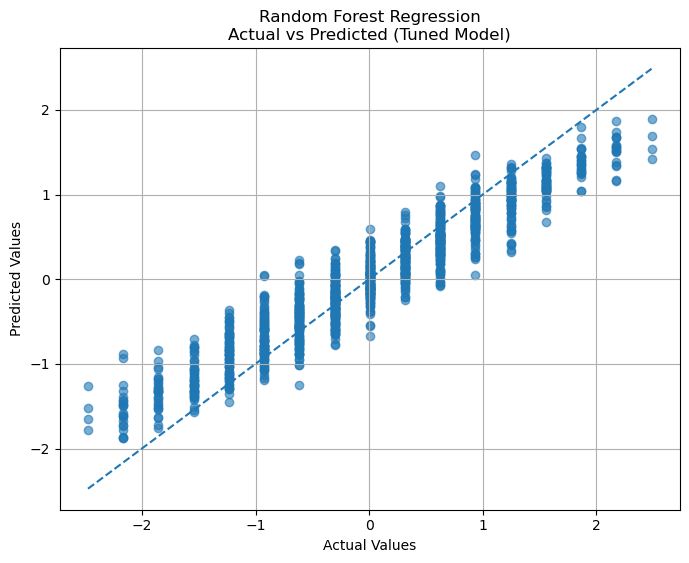

In [45]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_test_pred_rf, alpha=0.6)
plt.plot(
    [min(y_test), max(y_test)],
    [min(y_test), max(y_test)],
    linestyle='--'
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Random Forest Regression\nActual vs Predicted (Tuned Model)")
plt.grid(True)
plt.show()

It performs very well and also captures most of the variations in the data and make accurate predictions overall. It is a good and reliable model for this dataset.

#### Learning Curve

[learning_curve] Training set sizes: [ 387  774 1162 1549 1937 2324 2711 3099 3486 3874]


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:   32.8s finished


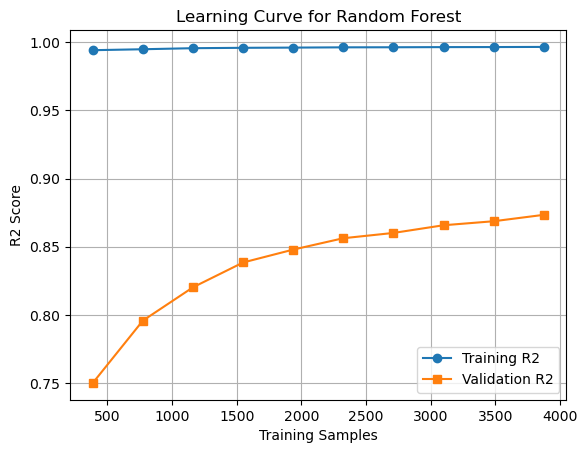

In [46]:
train_sizes, train_scores, test_scores = learning_curve(estimator=best_rf_model , X=X_train, y=y_train, cv=5, scoring='r2', train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1, verbose=1)


train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)


plt.plot(train_sizes, train_mean, marker='o', label='Training R2')
plt.plot(train_sizes, test_mean, marker='s', label='Validation R2')

plt.title("Learning Curve for Random Forest")
plt.xlabel("Training Samples")
plt.ylabel("R2 Score")
plt.grid(True)
plt.legend()
plt.show()

### SVR

In [47]:
from sklearn.svm import SVR

svr = SVR()
svr.fit(X_train, y_train)

y_train_pred_svr = svr.predict(X_train)
y_test_pred_svr = svr.predict(X_test)

train_acc = r2_score(y_train, y_train_pred_svr)
test_acc = r2_score(y_test, y_test_pred_svr)

print(f"r2 score for train: {train_acc}")
print(f"r2 score for test: {test_acc}")
print(f"mse for train: {mean_squared_error(y_train, y_train_pred_svr)}")
print(f"mse for test: {mean_squared_error(y_test, y_test_pred_svr)}")
cv_scores = cross_val_score(svr, X_train, y_train, cv=5, scoring='r2')
print(f"CV scores:{cv_scores}")
print(f"Average CV score:{cv_scores.mean()}")

r2 score for train: 0.9897861532740362
r2 score for test: 0.9795854088031926
mse for train: 0.01030449336396786
mse for test: 0.019684520237657495
CV scores:[0.97745517 0.97947555 0.97760308 0.97674557 0.98201497]
Average CV score:0.978658867021626


#### Hyperparameter Tuning

In [48]:
from scipy.stats import reciprocal, uniform

svr_param_dist = {
    'kernel': ['rbf', 'linear', 'poly', 'sigmoid'],
    'C': reciprocal(0.1, 1000),  
    'gamma': reciprocal(0.001, 1),
    'epsilon': uniform(0.01, 1)
}

svr = SVR()

svr_random_search = RandomizedSearchCV(estimator=svr, param_distributions=svr_param_dist, n_iter=50, cv=5, scoring='r2', verbose=1, random_state=42, n_jobs=-1)

svr_random_search.fit(X_train, y_train) 

print(f"Best SVR parameters: {svr_random_search.best_params_}")
print(f"Best SVR R2 score: {svr_random_search.best_score_}")
best_svr_model = svr_random_search.best_estimator_

train_r2 = best_svr_model.score(X_train, y_train)
test_r2 = best_svr_model.score(X_test, y_test)
y_test_pred_svr = best_svr_model.predict(X_test)
y_train_pred_svr = best_svr_model.predict(X_train)
test_rmse = mean_squared_error(y_test, y_test_pred_svr, squared=False)
print(f"SVR Train R2: {train_r2}")
print(f"SVR Test R2: {test_r2}")
print(f"SVR Test RMSE: {test_rmse}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best SVR parameters: {'C': 10.249816559563204, 'epsilon': 0.061478751249989354, 'gamma': 0.006853925708853058, 'kernel': 'rbf'}
Best SVR R2 score: 0.984557075095951
SVR Train R2: 0.9880214562455801
SVR Test R2: 0.9845691180095795
SVR Test RMSE: 0.12197966839417224


#### Predicted v/s Actual

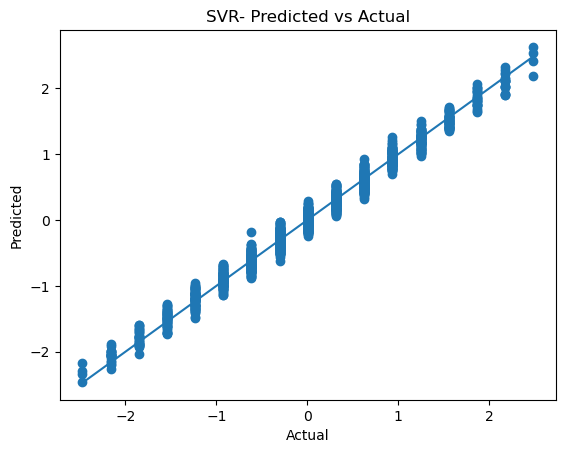

In [49]:
plt.scatter(y_test, y_test_pred_svr)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("SVR- Predicted vs Actual")
plt.show()

#### Learning Curve

[learning_curve] Training set sizes: [ 387  774 1162 1549 1937 2324 2711 3099 3486 3874]


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:   13.8s finished


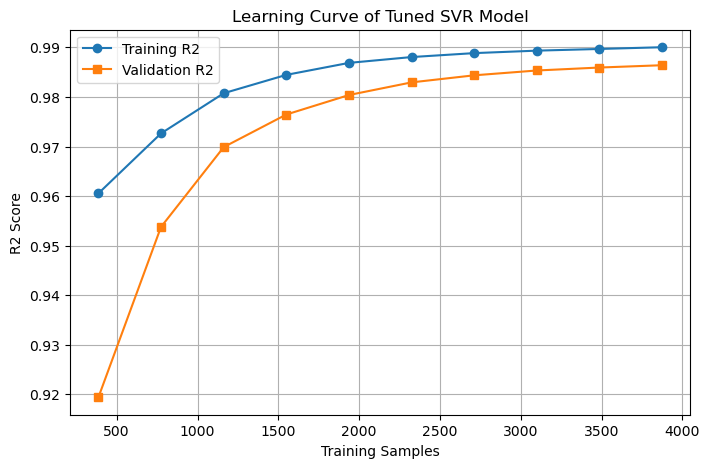

In [50]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', best_svr_model)
])

train_sizes, train_scores, test_scores = learning_curve(estimator=pipeline, X=X_train, y=y_train, cv=5, scoring='r2', train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1, verbose=1)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mean, marker='o', label='Training R2')
plt.plot(train_sizes, test_mean, marker='s', label='Validation R2')
plt.title("Learning Curve of Tuned SVR Model")
plt.xlabel("Training Samples")
plt.ylabel("R2 Score")
plt.grid(True)
plt.legend()
plt.show()

### Gradient Boosting Regressor

In [51]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor()
gbr.fit(X_train, y_train)

y_train_pred_gbr = gbr.predict(X_train)
y_test_pred_gbr = gbr.predict(X_test)

train_acc = r2_score(y_train, y_train_pred_gbr)
test_acc = r2_score(y_test, y_test_pred_gbr)

print(f"r2 score for train: {train_acc}")
print(f"r2 score for test: {test_acc}")
print(f"mse for train: {mean_squared_error(y_train, y_train_pred_gbr)}")
print(f"mse for test: {mean_squared_error(y_test, y_test_pred_gbr)}")
cv_scores = cross_val_score(gbr, X_train, y_train, cv=5, scoring='r2')
print(f"CV scores:{cv_scores}")
print(f"Average CV score:{cv_scores.mean()}")

r2 score for train: 0.9563793324266865
r2 score for test: 0.933670022083723
mse for train: 0.04400779565239101
mse for test: 0.0639578711162494
CV scores:[0.93848172 0.94098839 0.9352258  0.94186025 0.94094483]
Average CV score:0.9395001985264667


#### Hyperparameter Tuning

In [52]:
gbr_param_dist = {
    'n_estimators': np.arange(100, 1000, 100),
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3], 
    'max_depth': np.arange(3, 8),
    'min_samples_split': np.arange(2, 20),
    'min_samples_leaf': np.arange(1, 10),
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'max_features': ['sqrt', 'log2', None]
}
gbr = GradientBoostingRegressor(random_state=42)

gbr_random_search = RandomizedSearchCV(estimator=gbr, param_distributions=gbr_param_dist, n_iter=50, cv=5, scoring='r2', random_state=42, n_jobs=-1)

gbr_random_search.fit(X_train, y_train)

print(f"Best GBR parameters: {gbr_random_search.best_params_}")
print(f"Best GBR R2 score: {gbr_random_search.best_score_}")
best_gbr_model = gbr_random_search.best_estimator_

y_test_pred_gbr = best_gbr_model.predict(X_test)
y_train_predi_gbr = best_gbr_model.predict(X_train)
tuned_r2 = r2_score(y_test, y_test_pred_gbr)
tuned_rmse = np.sqrt(mean_squared_error(y_test,y_test_pred_gbr ))

print(f"GBR Test R2: {tuned_r2}")
print(f"GBR Test RMSE: {tuned_rmse}")

Best GBR parameters: {'subsample': 0.7, 'n_estimators': 900, 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': None, 'max_depth': 3, 'learning_rate': 0.1}
Best GBR R2 score: 0.9839258499248956
GBR Test R2: 0.9836583446078706
GBR Test RMSE: 0.12552785201242692


#### Actual v/s Predicted

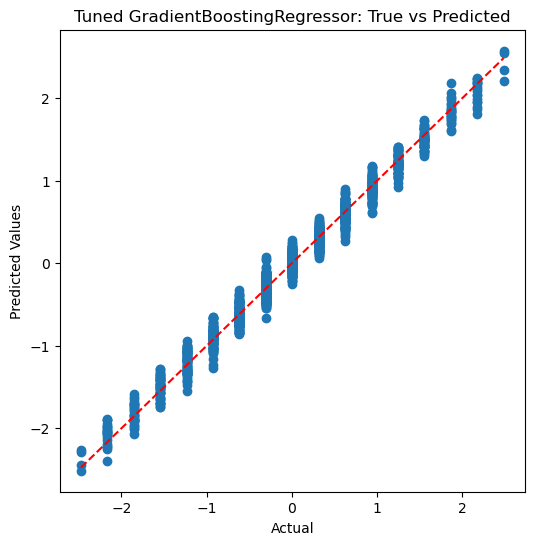

In [53]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test_pred_gbr)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted Values")
plt.title("Tuned GradientBoostingRegressor: True vs Predicted")
plt.show()

This model works extremely well, the model fits the data almost perfectly.

### Adaboost

In [54]:
from sklearn.ensemble import AdaBoostRegressor

ada = AdaBoostRegressor(
    n_estimators=100, 
    learning_rate=0.1,
    random_state=42
)

ada.fit(X_train, y_train)

y_train_pred_abr = ada.predict(X_train)
y_test_pred_abr = ada.predict(X_test)


train_r2 = r2_score(y_train, y_train_pred_abr)
test_r2 = r2_score(y_test, y_test_pred_abr)

train_mse = mean_squared_error(y_train, y_train_pred_abr)
test_mse = mean_squared_error(y_test, y_test_pred_abr)

print("Train R²:", train_r2)
print("Test R²:", test_r2)
print("Train MSE:", train_mse)
print("Test MSE:", test_mse)

Train R²: 0.729340682380184
Test R²: 0.7007491258477596
Train MSE: 0.2730613858948712
Test MSE: 0.2885490006436023


#### Hyperparameter Tuning

In [55]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

ada = AdaBoostRegressor(random_state=42)

param_dist = {
    'n_estimators': np.arange(50, 500, 50),
    'learning_rate': np.linspace(0.01, 1.0, 20),
    'loss': ['linear', 'square', 'exponential']
}

ada_random = RandomizedSearchCV(
    estimator=ada,
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

ada_random.fit(X_train, y_train)

print("Best Params:", ada_random.best_params_)
print("Best CV R2:", ada_random.best_score_)

best_ada = ada_random.best_estimator_

y_test_pred_abr = best_ada.predict(X_test)
y_train_pred_abr = best_ada.predict(X_train)
test_r2 = r2_score(y_test, y_test_pred_abr)
test_rmse = mean_squared_error(y_test, y_test_pred_abr, squared=False)

print("Test R2 (Tuned):", test_r2)
print("Test RMSE (Tuned):", test_rmse)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Params: {'n_estimators': 250, 'loss': 'square', 'learning_rate': 1.0}
Best CV R2: 0.8598934781168106
Test R2 (Tuned): 0.8489205411526255
Test RMSE (Tuned): 0.38167593984522036


#### Actual v/s Predicted

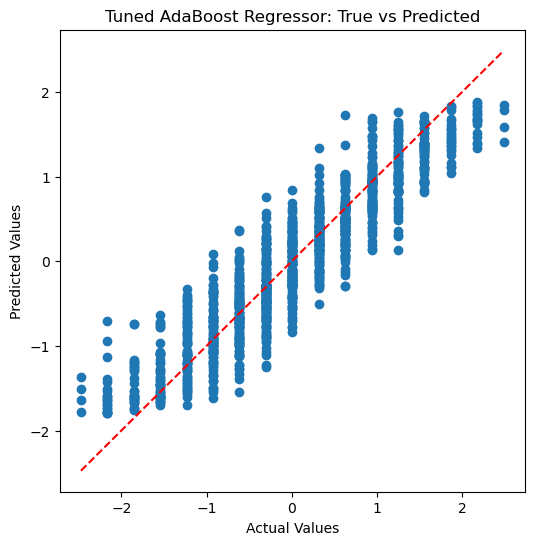

In [56]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test_pred_abr)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Tuned AdaBoost Regressor: True vs Predicted")
plt.show()

It also gives good performance and captures most of the patterns in the data but it is not that of a strong model.

### Important Features

Since SVR does so well (as per R2 Score), we try to see which features are most important with permutation_importance.

Feature importances:
Attendance: 1.0380277938291678
Hours_Studied: 0.5677187152816807
Previous_Scores: 0.10048239112600563
Parental_Involvement: 0.08289746806386131
Access_to_Resources: 0.08254078389073814
Tutoring_Sessions: 0.049604988429885796
Parental_Education_Level: 0.028181519459028824
Peer_Influence: 0.027813749271976607
Family_Income: 0.025069846738380364
Motivation_Level: 0.022369439617395327
Distance_from_Home: 0.021730549739007298
Learning_Disabilities: 0.018667121214938697
Teacher_Quality: 0.015920605125638733
Internet_Access: 0.01396129976431324
Extracurricular_Activities: 0.01206592713829272
Physical_Activity: 0.011802702167201595
Sleep_Hours: 8.813415288519977e-05
School_Type: -2.7457802363684003e-05
Gender: -3.1016028746977396e-05


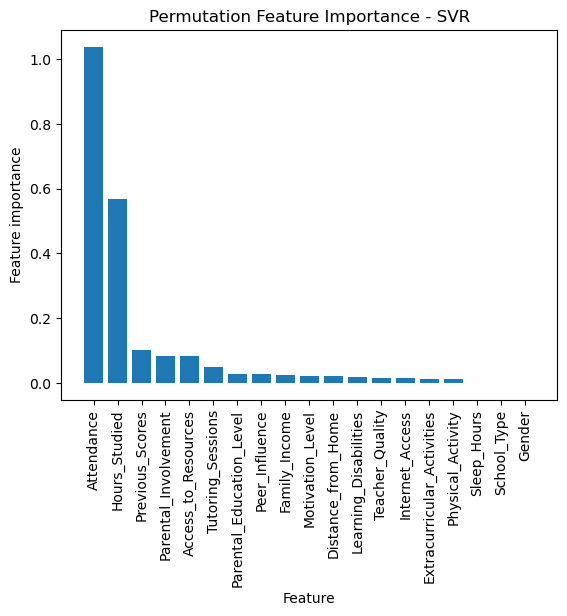

In [57]:
from sklearn.inspection import permutation_importance

result = permutation_importance(best_svr_model, X_test, y_test, scoring='r2', n_repeats=10, random_state=42)

importances = result.importances_mean
indices = np.argsort(importances)[::-1]

print("Feature importances:")
for i in indices:
    print(f"{X_train.columns[i]}: {importances[i]}")

plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), X_train.columns[indices], rotation=90)
plt.xlabel('Feature')
plt.ylabel('Feature importance')
plt.title("Permutation Feature Importance - SVR")
plt.show()

We calculate the feature importances with sklearn's feature_importance_ attribute for random forests as well.

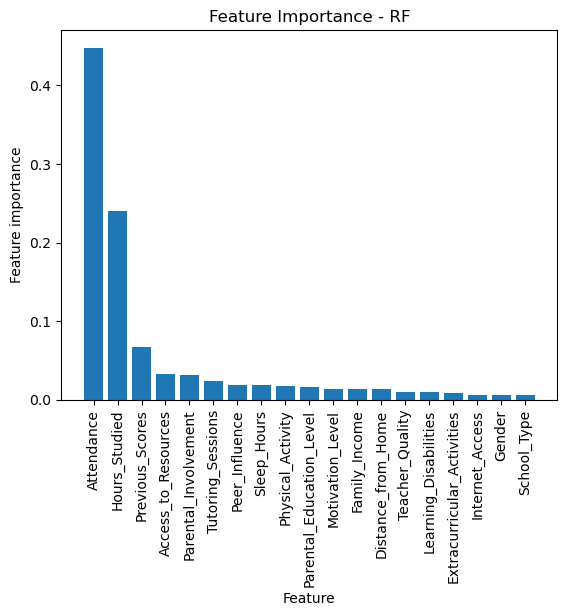

In [58]:
feat_imp = best_rf_model.feature_importances_
feat_ind = np.argsort(feat_imp)[::-1]
plt.bar(X_train.columns[feat_ind], feat_imp[feat_ind])
plt.xticks(range(len(feat_imp)), X_train.columns[feat_ind], rotation=90)
plt.xlabel('Feature')
plt.ylabel('Feature importance')
plt.title("Feature Importance - RF")
plt.show()

Feature importances:
Attendance: 1.046171321898643
Hours_Studied: 0.5723548471271653
Previous_Scores: 0.10230497205283391
Parental_Involvement: 0.0959831180391917
Access_to_Resources: 0.09463718804151136
Tutoring_Sessions: 0.050091700329414936
Parental_Education_Level: 0.02985444766777954
Peer_Influence: 0.027635584501187804
Family_Income: 0.026598159613719297
Motivation_Level: 0.02492941255402904
Distance_from_Home: 0.021250090414240676
Learning_Disabilities: 0.018448293732137487
Teacher_Quality: 0.01802099542710648
Internet_Access: 0.013754337738745492
Extracurricular_Activities: 0.0123644809059821
Physical_Activity: 0.011651541761646534
Sleep_Hours: 0.00013881498161674166
School_Type: -1.5173625739717256e-05
Gender: -3.4179418620983173e-05


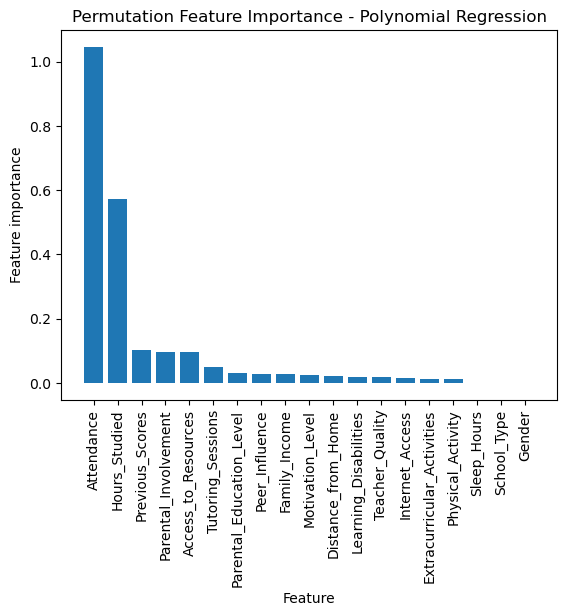

In [59]:
result = permutation_importance(best_poly_model, X_test, y_test, scoring='r2', n_repeats=10, random_state=42)

importances = result.importances_mean
indices = np.argsort(importances)[::-1]

print("Feature importances:")
for i in indices:
    print(f"{X_train.columns[i]}: {importances[i]}")

plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), X_train.columns[indices], rotation=90)
plt.xlabel('Feature')
plt.ylabel('Feature importance')
plt.title("Permutation Feature Importance - Polynomial Regression")
plt.show()

All the top models indicate that the most important features that determine a candidate's exam score are Attendance and Hours studied. All the other features contribute to the exam score much less than these do.

In [60]:
combined_results = pd.DataFrame({
    "Model": ["Linear Regression", "Polynomial Regression","LASSO","Ridge","DecisionTreeRegressor","RandomForestRegressor","SVR","GradientBoostingRegressor","AdaBoostRegressor"],
    "Train R2": [
        r2_score(y_train, y_train_pred_linear), 
        r2_score(y_train, y_train_pred_poly),
        r2_score(y_train, y_train_pred_lasso),
        r2_score(y_train, y_train_pred_ridge),
        r2_score(y_train, y_train_pred_dt),
        r2_score(y_train, y_train_pred_rf),
        r2_score(y_train, y_train_pred_svr),
        r2_score(y_train, y_train_pred_gbr),
        r2_score(y_train, y_train_pred_abr)
    ],
    "Test R2": [
        r2_score(y_test, y_test_pred_linear),
        r2_score(y_test, y_test_pred_poly),
        r2_score(y_test, y_test_pred_lasso),
        r2_score(y_test, y_test_pred_ridge),
        r2_score(y_test, y_test_pred_dt),
        r2_score(y_test, y_test_pred_rf),
        r2_score(y_test, y_test_pred_svr),
        r2_score(y_test, y_test_pred_gbr),
        r2_score(y_test, y_test_pred_abr)
    ],
    "Train MSE": [
        mean_squared_error(y_train, y_train_pred_linear),
        mean_squared_error(y_train, y_train_pred_poly),
        mean_squared_error(y_train, y_train_pred_lasso),
        mean_squared_error(y_train, y_train_pred_ridge),
        mean_squared_error(y_train, y_train_pred_dt),
        mean_squared_error(y_train, y_train_pred_rf),
        mean_squared_error(y_train, y_train_pred_svr),
        mean_squared_error(y_train, y_train_pred_gbr),
        mean_squared_error(y_train, y_train_pred_abr)
    ],
    "Test MSE": [
        mean_squared_error(y_test, y_test_pred_linear),
        mean_squared_error(y_test, y_test_pred_poly),
        mean_squared_error(y_test, y_test_pred_lasso),
        mean_squared_error(y_test, y_test_pred_ridge), 
        mean_squared_error(y_test, y_test_pred_dt),
        mean_squared_error(y_test, y_test_pred_rf),
        mean_squared_error(y_test, y_test_pred_svr),
        mean_squared_error(y_test, y_test_pred_gbr),
        mean_squared_error(y_test, y_test_pred_abr)
    ]
})

combined_results

,Model,Train R2,Test R2,Train MSE,Test MSE
0,Linear Regression,0.885849,0.873044,0.115164,0.122416
1,Polynomial Regression,0.990239,0.988745,0.009847,0.010852
2,LASSO,0.885848,0.873028,0.115165,0.122431
3,Ridge,0.885849,0.873044,0.115164,0.122416
4,DecisionTreeRegressor,0.855775,0.747591,0.145505,0.243382
5,RandomForestRegressor,0.996553,0.872427,0.003478,0.123011
6,SVR,0.988021,0.984569,0.012085,0.014879
7,GradientBoostingRegressor,0.956379,0.983658,0.044008,0.015757
8,AdaBoostRegressor,0.872935,0.848921,0.128192,0.145677
